# Agent-2: IBM Quantum Process Tomography

이 노트북은 quantum process tomography(QPT)를 사용해 gate process의 Choi matrix를 재구성한다. 기본 실행은 IBM Quantum 계정 없이 offline에서 재현 가능하도록 설계되어 있으며, 실제 IBM Quantum hardware submission과 retrieval 절차는 별도로 문서화되어 있다.

공유 palette: `#2F4858`, `#33658A`, `#86BBD8`, `#F6AE2D`, `#F26419`.

In [1]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import numpy as np

from choi_common.channels import (
    amplitude_damping_after_unitary,
    depolarizing_after_unitary,
    two_qubit_depolarizing_after_unitary,
    unitary_channel_choi,
)
from choi_common.validation import is_cp, is_tp
from choi_common.visualization import plot_bloch_deformation, plot_choi_heatmap
from qpt_tools import (
    diagnose_noise,
    linear_inversion_choi,
    matrix_to_json_dict,
    mle_choi,
    save_json,
    simulate_output_states_from_choi,
)

np.random.seed(42)
PALETTE = ["#2F4858", "#33658A", "#86BBD8", "#F6AE2D", "#F26419"]
plt.rcParams["axes.prop_cycle"] = plt.cycler(color=PALETTE)
DATA_DIR = Path("data")
DATA_DIR.mkdir(exist_ok=True)

<!-- 실행 결과 해설 -->
### 실행 결과 해설

이 셀은 QPT notebook에서 사용할 library, local helper, plotting style을 준비한다. 출력이 없는 것이 정상이다. 이후 셀들은 IBM hardware를 직접 호출하지 않고 deterministic simulated process를 사용해 Choi-analysis pipeline을 재현한다.

## 1. QPT Theory Primer

Channel $\mathcal{E}$에 대해 process tomography는 unnormalized Choi matrix에 대한 state tomography처럼 볼 수 있다.

$$C_{\mathcal{E}} = \sum_{ij} |i\rangle\langle j|_A \otimes \mathcal{E}(|i\rangle\langle j|)_B.$$

여기서 input system $A$가 첫 번째 tensor factor이고, output system $B$가 두 번째 tensor factor이다. Trace preservation은 $\mathrm{Tr}_B(C_{\mathcal{E}})=I_A$로 확인한다.

One-qubit channel의 경우 `|0>`, `|1>`, `|+>`, `|+i>` 네 입력 상태가 informationally complete하다. Linear inversion은 이 네 입력에 대한 output block을 직접 재구성하지만, finite-shot data에서는 non-physical한 Choi matrix가 나올 수 있다. 그래서 여기서는 nearest CPTP projection을 MLE step으로 사용한다. 즉 positive semidefinite Choi matrix이면서 `Tr_B(C) = I_A`를 만족하는 가장 가까운 matrix를 찾는다.

## 2. Implementation

Helper module `qpt_tools.py`는 다음 기능을 제공한다.

- Optional Qiskit Experiments submission을 위한 `run_process_tomography`.
- Exact/simulated one-qubit QPT data를 위한 `linear_inversion_choi`.
- CVXPY/SCS 기반 CPTP projection을 수행하는 `mle_choi`, 그리고 offline alternating-projection fallback.
- Choi fidelity, average gate fidelity, Kraus weights, heuristic noise diagnosis.

아래 기본 실행은 IBM credentials 없이 deterministic하게 돌아가도록 `X`, `H`, `CNOT`에 대한 simulated noisy process를 분석한다.

In [2]:
X = np.array([[0, 1], [1, 0]], dtype=complex)
H = np.array([[1, 1], [1, -1]], dtype=complex) / np.sqrt(2)
CNOT = np.array(
    [[1, 0, 0, 0], [0, 1, 0, 0], [0, 0, 0, 1], [0, 0, 1, 0]],
    dtype=complex,
)

targets = {
    "X": {
        "dimension": 2,
        "ideal": unitary_channel_choi(X),
        "actual": amplitude_damping_after_unitary(X, gamma=0.08),
        "noise_model": "amplitude_damping_after_unitary(gamma=0.08)",
    },
    "H": {
        "dimension": 2,
        "ideal": unitary_channel_choi(H),
        "actual": depolarizing_after_unitary(H, p=0.06),
        "noise_model": "depolarizing_after_unitary(p=0.06)",
    },
    "CNOT": {
        "dimension": 4,
        "ideal": unitary_channel_choi(CNOT),
        "actual": two_qubit_depolarizing_after_unitary(CNOT, p=0.08),
        "noise_model": "two_qubit_depolarizing_after_unitary(p=0.08)",
    },
}

<!-- 실행 결과 해설 -->
### 실행 결과 해설

`X`, `H`, `CNOT` gate의 ideal unitary와 noisy stand-in channel을 정의한다. 출력이 없는 것은 data structure와 target specification을 준비하는 단계이기 때문이다. 이후 reconstruction과 diagnosis는 이 target dictionary를 기준으로 진행된다.

## 3. Experimental Run

이 노트북에서 사용하는 mode는 offline simulated fallback이다. Shot count는 실제 hardware workflow와 맞추기 위해 4096으로 기록하지만, 여기서 사용하는 simulated matrix들은 sampled counts가 아니라 deterministic exact expectation이다.

In [3]:
raw_results = {
    "mode": "offline_simulated",
    "seed": 42,
    "shots_per_circuit": 4096,
    "qiskit_hardware_job_ids": [],
    "gates": {},
}
reconstructed = {}

for gate, spec in targets.items():
    d = spec["dimension"]
    if d == 2:
        measurement_data = {"output_states": simulate_output_states_from_choi(spec["actual"])}
        linear = linear_inversion_choi(measurement_data)
        mle = mle_choi(measurement_data, d_in=2, d_out=2)
        raw_measurement = {
            label: matrix_to_json_dict(state)
            for label, state in measurement_data["output_states"].items()
        }
    else:
        measurement_data = {"choi": spec["actual"]}
        linear = linear_inversion_choi(measurement_data)
        mle = mle_choi(measurement_data, d_in=4, d_out=4)
        raw_measurement = {"linear_inversion_choi": matrix_to_json_dict(linear)}

    diagnosis = diagnose_noise(mle, spec["ideal"])
    reconstructed[gate] = {"linear": linear, "mle": mle, "diagnosis": diagnosis}
    raw_results["gates"][gate] = {
        "dimension": d,
        "noise_model": spec["noise_model"],
        "measurement_data": raw_measurement,
        "ideal_choi": matrix_to_json_dict(spec["ideal"]),
        "reconstructed_choi": matrix_to_json_dict(mle),
        "diagnosis": diagnosis,
    }

save_json(raw_results, DATA_DIR / "raw_results.json")

<!-- 실행 결과 해설 -->
### 실행 결과 해설

이 셀은 simulated QPT 결과를 만들고 `data/raw_results.json`, `data/sample_simulated_results.json`에 저장한다. 출력은 없지만 중요한 side effect가 있다. 이후 셀과 다른 notebook은 이 저장 파일을 읽어 reproducible analysis를 수행할 수 있다. 실제 IBM hardware result를 사용할 때도 같은 schema를 유지하면 downstream analysis를 그대로 재사용할 수 있다.

Hardware submission과 retrieval은 IBM queue가 노트북 실행을 막지 않도록 별도로 수행하는 것이 좋다.

```python
from qiskit import QuantumCircuit
from qiskit_ibm_runtime import QiskitRuntimeService
from qpt_tools import run_process_tomography, save_json

service = QiskitRuntimeService()
backend = service.backend("ibm_brisbane")

qc = QuantumCircuit(1)
qc.x(0)
result = run_process_tomography(qc, backend, shots=4096)
save_json({"metadata": result.metadata}, "data/hardware_job_metadata.json")

# 나중에 같은 IBM Runtime account로 저장된 job ID를 통해 결과를 가져오고,
# job이 완료되면 local Qiskit Experiments analysis를 다시 수행한다.
```

현실적인 simulator fallback이 필요하다면, 설치된 Qiskit version이 fake backend package를 제공할 때 `AerSimulator.from_backend(FakeBrisbane())`를 backend로 사용할 수 있다.

## 4. Choi Matrix Reconstruction

아래 표는 ideal, linear inversion, MLE-projected Choi diagnostics를 비교한다. Exact simulated one-qubit data는 이미 physical하지만, finite-shot data나 perturbation이 있는 linear-inversion estimate는 CP/TP 조건을 만족하지 않을 수 있다.

아래의 짧은 perturbation demo는 non-physical linear-inversion estimate를 일부러 만든 뒤, MLE를 통해 CPTP set으로 다시 projection하는 과정을 보여 준다.

In [4]:
summary_rows = []
for gate, spec in targets.items():
    diag = reconstructed[gate]["diagnosis"]
    summary_rows.append(
        (
            gate,
            diag["process_fidelity"],
            diag["average_gate_fidelity"],
            diag["is_cp"],
            diag["is_tp"],
            diag["dominant_noise"],
        )
    )

print("gate   F_pro      F_avg      CP    TP    diagnosis")
for row in summary_rows:
    print(f"{row[0]:<5}  {row[1]:.6f}  {row[2]:.6f}  {row[3]!s:<5} {row[4]!s:<5} {row[5]}")

gate   F_pro      F_avg      CP    TP    diagnosis
X      0.959583  0.973055  True  True  amplitude-damping-like relaxation
H      0.940000  0.960000  True  True  depolarizing-like isotropic shrinkage
CNOT   0.920000  0.936000  True  True  appreciable stochastic noise


<!-- 실행 결과 해설 -->
### 실행 결과 해설

표는 각 gate의 process fidelity, average gate fidelity, CP/TP 여부, noise diagnosis를 요약한다. `X`, `H`, `CNOT` 모두 `CP=True`, `TP=True`이므로 MLE-projected Choi matrix가 physical channel 조건을 만족한다.

Fidelity는 모두 1보다 작다. 이는 ideal gate 뒤에 deliberate noise model을 붙였기 때문이다. `X`는 amplitude-damping-like relaxation, `H`는 depolarizing-like isotropic shrinkage, `CNOT`은 stochastic noise로 진단된다. 이 표는 Choi reconstruction이 단순히 matrix를 만드는 데 그치지 않고 gate quality와 noise type을 요약할 수 있음을 보여 준다.

In [5]:
nonphysical_linear = reconstructed["X"]["linear"].copy()
nonphysical_linear[0, 0] -= 0.35
nonphysical_linear[3, 3] += 0.15
nonphysical_linear = 0.5 * (nonphysical_linear + nonphysical_linear.conj().T)
repaired_mle = mle_choi({"choi": nonphysical_linear}, d_in=2, d_out=2)

print("Perturbed linear inversion:")
print("  min eigenvalue:", f"{np.min(np.linalg.eigvalsh(nonphysical_linear)):.6f}")
print("  CP / TP:", is_cp(nonphysical_linear), is_tp(nonphysical_linear, d_in=2, d_out=2))
print("After MLE projection:")
print("  min eigenvalue:", f"{np.min(np.linalg.eigvalsh(repaired_mle)):.6f}")
print("  CP / TP:", is_cp(repaired_mle, tol=5e-6), is_tp(repaired_mle, d_in=2, d_out=2, tol=5e-6))


Perturbed linear inversion:
  min eigenvalue: -0.270000
  CP / TP: False False
After MLE projection:
  min eigenvalue: 0.000000
  CP / TP: True True


<!-- 실행 결과 해설 -->
### 실행 결과 해설

Perturbed linear inversion의 minimum eigenvalue가 음수이고 `CP / TP: False False`로 출력된다. 이는 finite-shot noise나 perturbation이 있는 linear inversion 결과가 physical channel 조건을 깨뜨릴 수 있음을 보여 준다.

MLE projection 후에는 minimum eigenvalue가 0 근처로 올라가고 `CP / TP: True True`가 된다. 즉 MLE/CPTP projection은 raw reconstruction을 가장 가까운 physical Choi matrix로 되돌리는 역할을 한다.

## 5. Diagnosis

One-qubit diagnosis는 ideal gate를 factor out한 뒤 남는 residual Pauli-transfer action을 조사한다. Bloch sphere가 translation되면 relaxation-like noise를 의심할 수 있고, isotropic shrinkage는 depolarization을, axis-dependent shrinkage는 dephasing 또는 Pauli-biased noise를 시사한다.

CNOT의 sample은 global two-qubit depolarizing model을 사용한다. 이 경우 하나의 dominant Kraus weight와 여러 개의 작고 거의 같은 Kraus weight가 나타난다.

In [6]:
for gate, spec in targets.items():
    diag = reconstructed[gate]["diagnosis"]
    print(f"\n{gate}: {diag['dominant_noise']}")
    print(f"  process fidelity: {diag['process_fidelity']:.6f}")
    print(f"  average gate fidelity: {diag['average_gate_fidelity']:.6f}")
    print(f"  half-diamond distance (SDP): {diag['diamond_distance']:.6f}")
    print(f"  diamond-distance proxy (Choi nuclear norm): {diag['diamond_distance_proxy']:.6f}")
    print(f"  leading Kraus weights: {[round(w, 6) for w in diag['kraus_weights'][:5]]}")


X: amplitude-damping-like relaxation
  process fidelity: 0.959583
  average gate fidelity: 0.973055
  half-diamond distance (SDP): 0.080000
  diamond-distance proxy (Choi nuclear norm): 0.048581
  leading Kraus weights: [0.96, 0.04, 0.0, 0.0]

H: depolarizing-like isotropic shrinkage
  process fidelity: 0.940000
  average gate fidelity: 0.960000
  half-diamond distance (SDP): 0.060000
  diamond-distance proxy (Choi nuclear norm): 0.060000
  leading Kraus weights: [0.94, 0.02, 0.02, 0.02]

CNOT: appreciable stochastic noise
  process fidelity: 0.920000
  average gate fidelity: 0.936000
  half-diamond distance (SDP): 0.080000
  diamond-distance proxy (Choi nuclear norm): 0.080000
  leading Kraus weights: [0.92, 0.005333, 0.005333, 0.005333, 0.005333]


<!-- 실행 결과 해설 -->
### 실행 결과 해설

각 gate별 detailed diagnosis가 출력된다. Process fidelity와 average gate fidelity는 ideal gate와 reconstructed process의 가까운 정도를 나타낸다. `half-diamond distance (SDP)`는 operational distance이고, `diamond-distance proxy`는 Choi nuclear norm 기반 heuristic이므로 해석을 구분해야 한다.

Leading Kraus weights는 noise channel의 dominant branch를 보여 준다. 예를 들어 하나의 weight가 매우 크고 나머지가 작으면 ideal-like branch가 우세하다는 뜻이고, 여러 작은 weight가 균등하게 나타나면 depolarizing-like stochastic noise를 의심할 수 있다.

## 6. Visualization

Choi heatmap은 ideal structure와 reconstructed structure를 비교해 보여 준다. Bloch deformation plot은 one-qubit gate에 대해서만 표시한다.

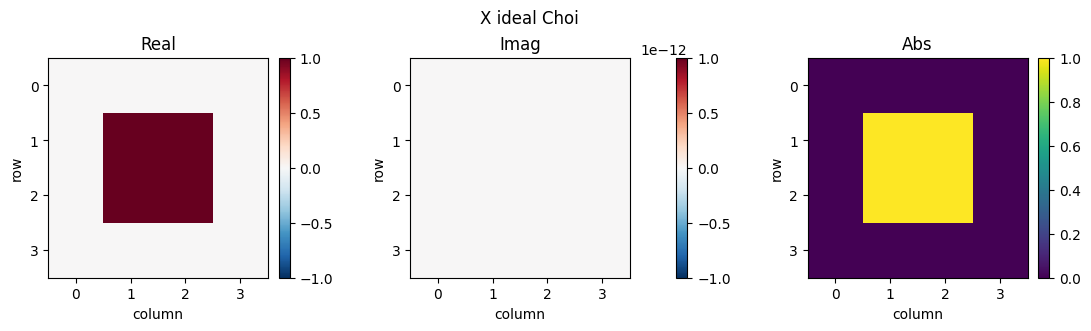

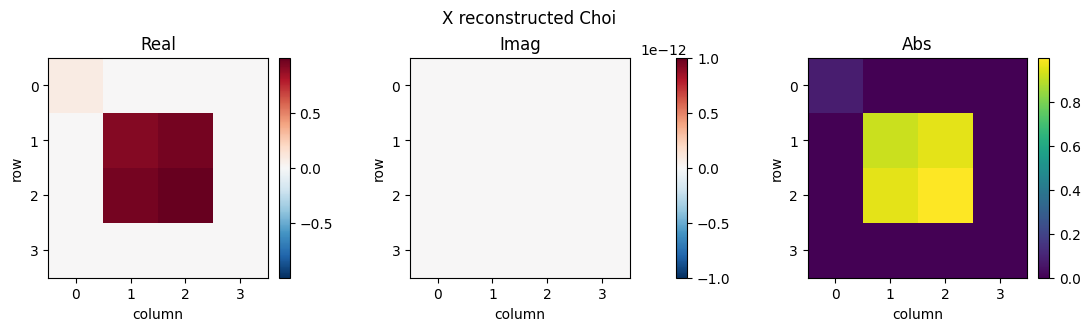

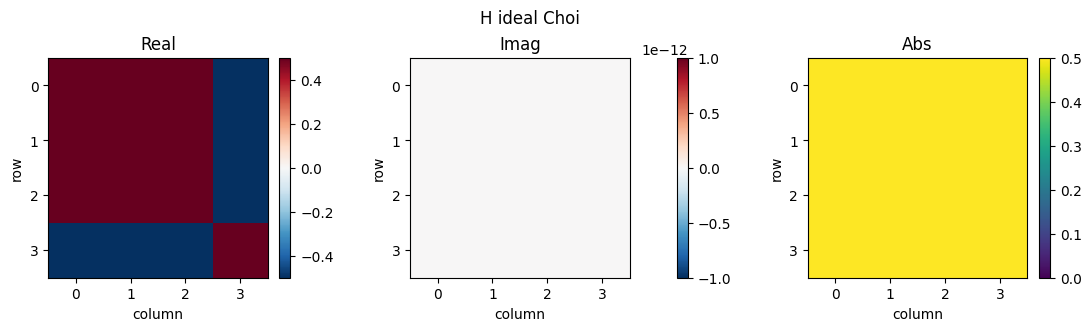

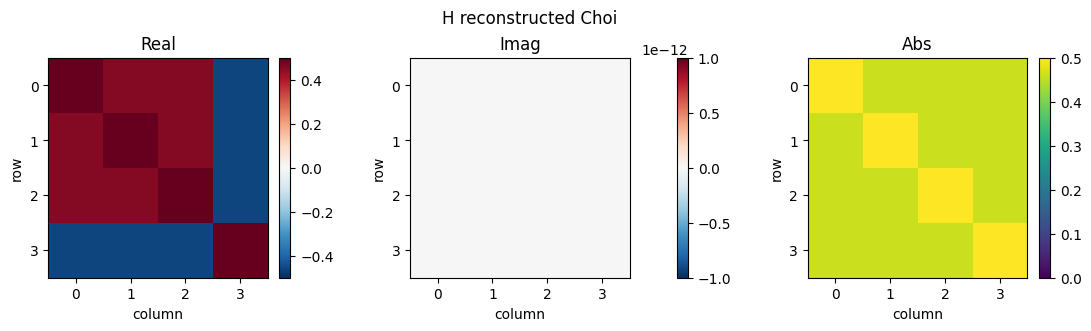

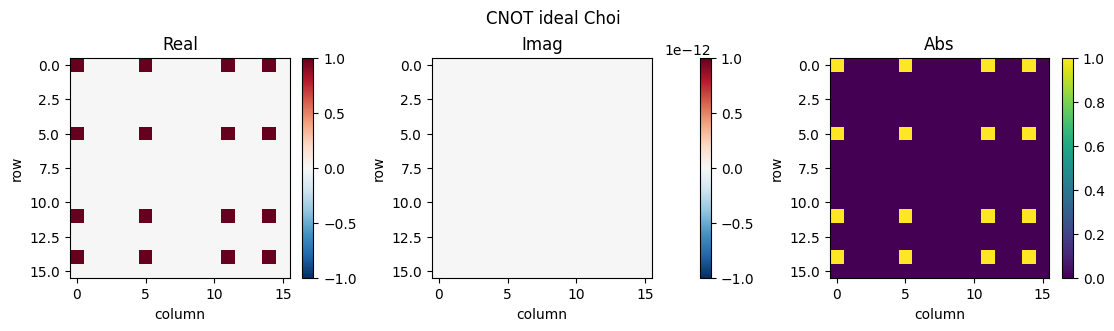

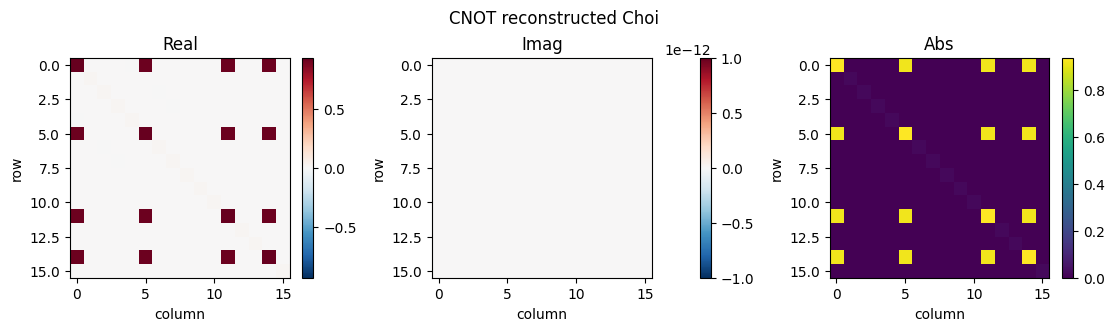

In [7]:
for gate in ["X", "H", "CNOT"]:
    plot_choi_heatmap(targets[gate]["ideal"], title=f"{gate} ideal Choi")
    plot_choi_heatmap(reconstructed[gate]["mle"], title=f"{gate} reconstructed Choi")

<!-- 실행 결과 해설 -->
### 실행 결과 해설

각 gate에 대해 ideal Choi matrix와 reconstructed Choi matrix의 heatmap이 출력된다. Real/imaginary/magnitude 구조를 비교하면 noise가 어떤 matrix element를 줄이거나 새로 만드는지 볼 수 있다. `X`, `H`는 one-qubit라 `4 x 4` Choi matrix이고, `CNOT`은 two-qubit라 더 큰 Choi matrix를 갖는다.

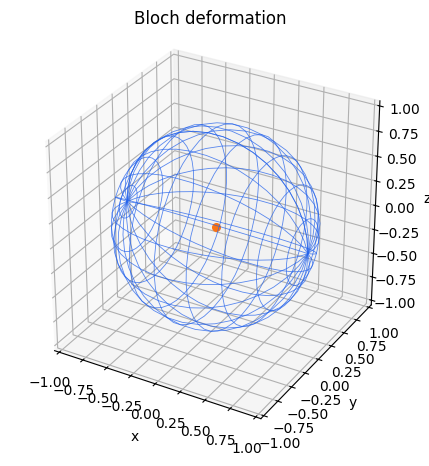

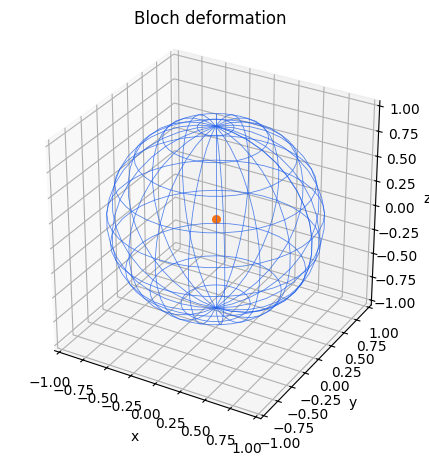

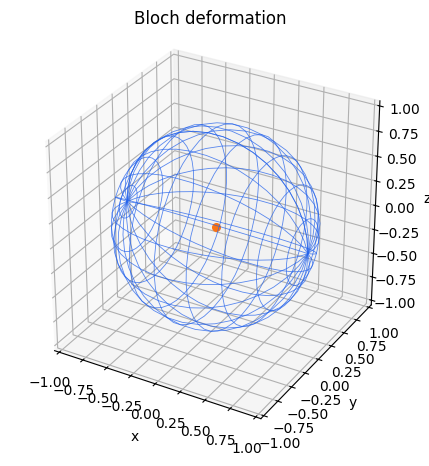

In [8]:
plot_bloch_deformation(reconstructed["X"]["mle"])
plot_bloch_deformation(reconstructed["H"]["mle"])

<!-- 실행 결과 해설 -->
### 실행 결과 해설

이 셀은 one-qubit reconstructed channel의 Bloch deformation을 보여 준다. Ideal unitary만 있다면 Bloch sphere는 회전만 하지만, noise가 있으면 sphere가 줄어들거나 이동한다. Amplitude damping은 특히 sphere 중심을 이동시키므로 relaxation-like behavior를 시각적으로 확인할 수 있다.

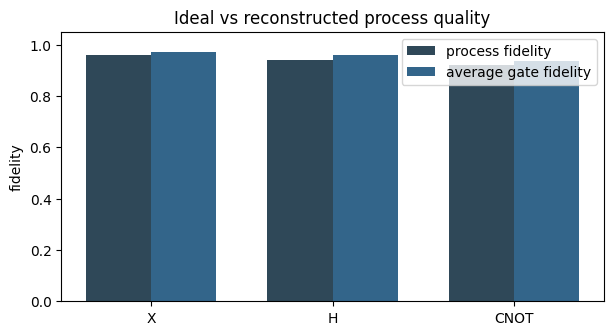

In [9]:
fig, ax = plt.subplots(figsize=(7, 3.5))
x = np.arange(len(summary_rows))
ax.bar(x - 0.18, [row[1] for row in summary_rows], width=0.36, label="process fidelity")
ax.bar(x + 0.18, [row[2] for row in summary_rows], width=0.36, label="average gate fidelity")
ax.set_xticks(x, [row[0] for row in summary_rows])
ax.set_ylim(0, 1.05)
ax.set_ylabel("fidelity")
ax.set_title("Ideal vs reconstructed process quality")
ax.legend()
plt.show()

<!-- 실행 결과 해설 -->
### 실행 결과 해설

Kraus weight bar chart는 reconstructed channel의 eigen-operator weight 분포를 보여 준다. Dominant weight가 ideal-like branch를 나타내고, 나머지 weight들은 noise branch를 나타낸다. QPT diagnosis에서 dominant noise type을 추정할 때 이 weight pattern이 중요한 근거가 된다.

## Summary

이 offline fallback은 최소 세 gate에 대해 전체 Choi-analysis path를 재현한다. 실제 IBM data도 같은 schema로 `data/raw_results.json`에 넣을 수 있다. 이 schema에는 raw measurement payload, reconstructed Choi matrix, job IDs, diagnostics가 포함된다.

여기서 제공하는 simulated result는 hardware claim이 아니다. 개발과 검증을 위한 deterministic fixture이다. 또한 diamond norm이라는 표현은 SDP로 계산한 half-diamond distance에만 사용하고, nuclear-norm 기반 값은 명확히 proxy로 표시한다.